# Calculate a high-resolution BeamFactor

This notebook calculates a high-resolution beam factor that can be interpolated and applied to any particular day in a fast way. The defaults are set in such a way as to reproduce Alan's beam factor, and to show this, we give an example of a couple of days in this notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from astropy import units as un
import numpy as np

from edges.sim import beams, sky_models, compute_antenna_beam_factor
from edges import const
from edges import modeling as mdl


In [2]:
outdir: str = "."
beamfile: str = '/data4/nmahesh/edges/code_from_alan_org/newniv.txt'  # probably should move this into the repo...

alandata: str = "/data4/smurray/edges/alans-pipeline/scripts/H2CaseFieldData/"

f_low: float = 40.0
f_high: float = 100.0
rotation_from_north: float = -6
lst_start: float = 0.0
dlst: float = 0.1
sky_model: str = "Haslam408AllNoh"
index_model: str = "ConstantIndex"
normalize_beam: bool = False
beam_smoothing: bool = False
interp_kind: str = 'nearest'
telescope = 'edges-low-alan'
sky_at_reference_frequency: bool = False
use_astropy_azel: bool = False

In [3]:
# Parameters
outdir = "."
dlst = 0.1


In [4]:
beam = beams.Beam.from_file(band='low', beam_file=beamfile, rotation_from_north=rotation_from_north)

In [5]:
lsts = np.arange(lst_start, lst_start + 24.0, dlst)

In [6]:
beamfac = compute_antenna_beam_factor(
    beam,
    f_low=f_low*un.MHz, 
    f_high=f_high*un.MHz, 
    lsts=lsts, 
    sky_model=getattr(sky_models, sky_model)(), 
    index_model= getattr(sky_models, index_model)(),
    normalize_beam=normalize_beam,
    reference_frequency=75*un.MHz,
    beam_smoothing=beam_smoothing,
    interp_kind=interp_kind,
    freq_progress=False,
    location=const.KNOWN_TELESCOPES[telescope].location,
    sky_at_reference_frequency=sky_at_reference_frequency,
    use_astropy_azel=use_astropy_azel
)

  0%|          | 0/240 [00:00<?, ?LST/s]

  0%|          | 1/240 [00:01<05:49,  1.46s/LST]

  1%|          | 2/240 [00:02<05:14,  1.32s/LST]

  1%|▏         | 3/240 [00:03<05:02,  1.28s/LST]

  2%|▏         | 4/240 [00:05<04:56,  1.26s/LST]

...

 99%|█████████▉| 237/240 [05:31<00:06,  2.18s/LST]

 99%|█████████▉| 238/240 [05:32<00:03,  1.89s/LST]

100%|█████████▉| 239/240 [05:33<00:01,  1.65s/LST]

100%|██████████| 240/240 [05:35<00:00,  1.48s/LST]

100%|██████████| 240/240 [05:35<00:00,  1.40s/LST]

In [7]:
h2casedir = Path(alandata)
dirs = [d for d in sorted(h2casedir.glob("???")) if d.is_dir()][:10]

In [8]:
fourier = mdl.Fourier(
    n_terms=31,
    transform=mdl.ShiftTransform(shift=75.0),
    period=1.2*beamfac.nfreq * (beamfac.frequencies[1] - beamfac.frequencies[0]),
)

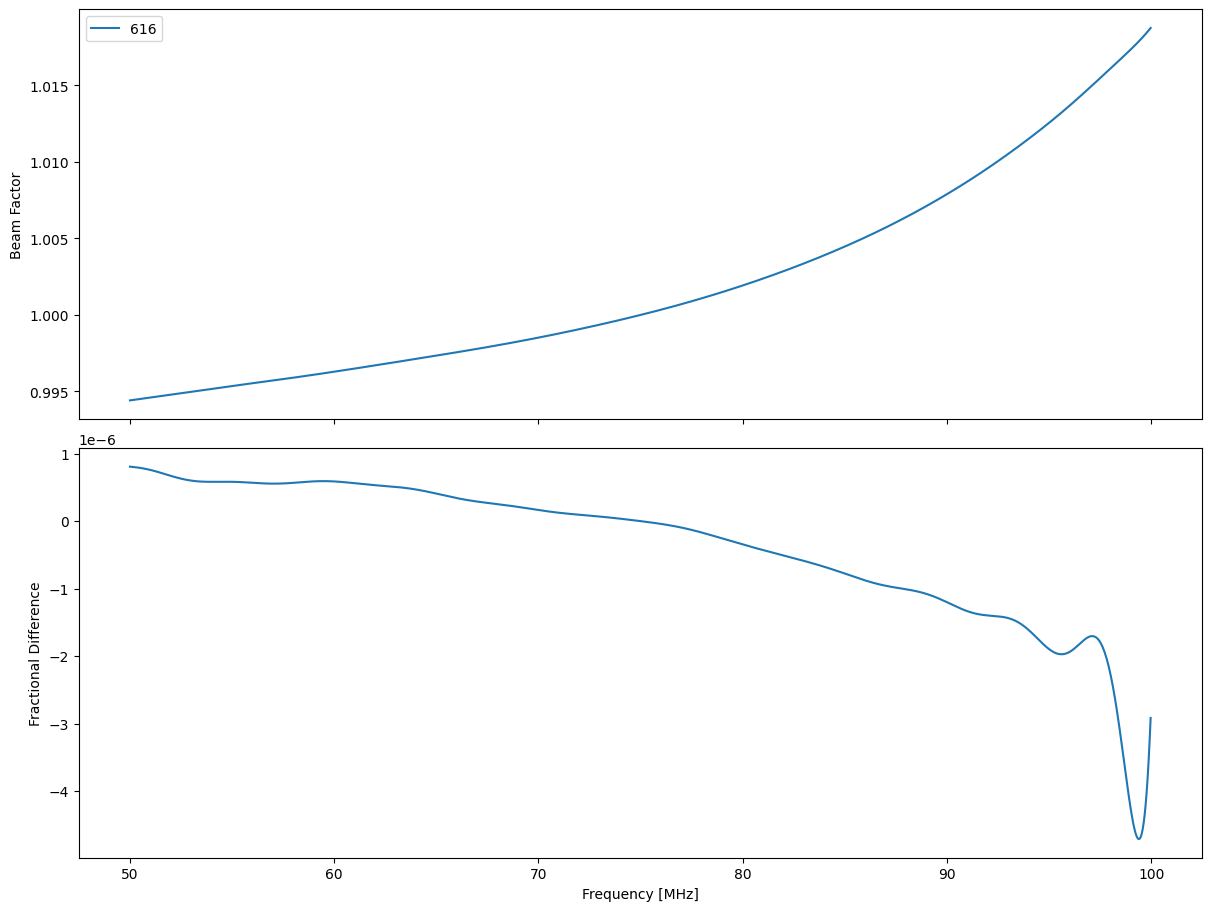

In [9]:

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 9),constrained_layout=True)

for day in dirs[:1]:
    if not (day / 'beamcorr.txt').exists():
        continue
    
    alandata = np.genfromtxt(day / 'beamcorr.txt')
    
    beamfacs = sorted(day.glob("beamfac*.txt"), key=lambda pth: int(pth.stem[7:]))
    
    # Get all lsts from outputs
    these_lsts = []
    for bf in beamfacs:
        with open(bf, 'r') as fl:
            these_lsts.append(float(fl.readlines()[1].split("=")[-1].strip()))
            
    these_lsts = np.unwrap(np.array(these_lsts), period=24.0)
    trunc = beamfac.at_lsts(np.array(these_lsts)).get_integrated_beam_factor(model=fourier, freqs=alandata[:, 0])
    ax[0].plot(alandata[:, 0], trunc, label=str(day.name))
    ax[1].plot(alandata[:, 0], (trunc*alandata[:,3] - 1))
    
ax[0].set_ylabel("Beam Factor")
ax[1].set_ylabel("Fractional Difference")
ax[1].set_xlabel("Frequency [MHz]")
ax[0].legend()

In [10]:
beamfac.write(Path(outdir) / "beam_factor.hickle")